# Shipment Delay Prediction

## Phase 1 : Data Overview

This notebook focuses on understanding the available datasets before performing any preprocessing or machine learning tasks. The objective of this phase is to explore the structure, quality, and characteristics of each dataset to identify potential issues and understand relationships among the available features.

## 1.1 Dataset Inventory

The project consists of multiple datasets representing different aspects of the shipment lifecycle. Each dataset contains information related to logistics operations such as shipment details, customer information, routes, vehicles, weather conditions, warehouses, customs, and delivery history.



## load the library 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## load the dataset

In [2]:

# Load all datasets
df_shipments = pd.read_csv("dataset/shipments.csv")
df_customers = pd.read_csv("dataset/customers.csv")
df_carriers = pd.read_csv("dataset/carriers.csv")
df_vehicles = pd.read_csv("dataset/vehicles.csv")
df_routes = pd.read_csv("dataset/routes.csv")
df_warehouses = pd.read_csv("dataset/warehouses.csv")
df_weather = pd.read_csv("dataset/weather.csv")
df_products = pd.read_csv("dataset/products.csv")
df_customs = pd.read_csv("dataset/customs.csv")
df_delivery_history = pd.read_csv("dataset/shipment_delivery_history.csv")

## 1.df_shipments

In [210]:
df_shipments.head()

,shipment_id,booking_id,customer_id,product_id,carrier_id,warehouse_id,route_id,vehicle_id,customs_id,weather_id,...,ship_date,expected_delivery_date,shipping_mode,shipment_type,priority,weight_kg,volume_cbm,declared_value,insurance,fragile
0,2fbc2ba7-78db-4cd4-abc4-8484f8e296c0,BK100000,9d07a288-d20c-4632-be32-a80646174f82,7d9bcdf2-1cf5-4fdd-ba64-30b5ab5770fe,1b55fff6-046a-4456-9cb0-b8cd21addf5a,c8447ce1-fe0b-4d5b-96c9-b9a275ad8a25,aa747821-06b3-495f-b000-1b2e8b911707,f5ca04c7-97ce-4489-bfc9-69bb578f9273,de1b0e23-43fb-4d0d-a84a-07337bbc6411,a79111db-721a-4600-b313-ae9ab7f6f924,...,2023-08-13,2023-09-12,Sea,Import,Standard,40.6,0.12,8237.48,False,False
1,1881d036-771b-4eb6-ae7a-ac78f41dfd79,BK100001,189fab37-8b05-4e69-b000-be0f6ec9dbc4,5d909ac1-2fad-4861-a19e-79e99e125dfe,2a4ec8f6-16fe-4936-ac67-37fc52238e51,632799e1-4e31-4ba3-838e-c12663328395,1a5d3872-1ddf-4ff8-93e7-07fc5acafc25,830c2f7a-afba-4df9-b8b9-b5e5e1489cee,1d81cb99-8755-4f4a-bc2e-1bb414bbbe42,db916c48-9524-4904-b0d0-6016baeb0a3c,...,2024-06-17,2024-06-22,Rail,Export,Standard,57.1,0.22,7133.89,True,False
2,db4bcd2c-d981-4b8a-b61c-83c6dae109d8,BK100002,32320649-068b-4887-b776-ab2d9941cb1a,b1eb6a65-e462-4da5-a91f-78d00b0c241f,22c1d43a-dc69-48e3-8df1-18788f0cc19a,931ea697-c860-4af1-a6c8-e86f72c220ba,ddfeb7c4-87b1-4916-b523-22df1f1c16f3,a33fbf71-6b09-4246-921e-dd0de3c4600f,7e7b4406-6108-4603-897f-0f852c9f8927,6afe8d32-c11d-453f-9ca2-482ccc2e029d,...,2023-11-27,2023-11-28,Sea,Export,Standard,19.3,0.06,1813.83,False,True
3,b0787b6f-8743-4765-a0e8-f0457edad4bf,BK100003,f9670081-1287-4dca-9d8c-4beffacc6dcc,02c94f60-6dc8-4db8-94db-866ee6e7e608,28d939e1-9282-48ee-9a14-a7290d7e0350,a73aac58-381d-4494-84d2-de0456a1c93b,707f01ba-3ee5-4157-9845-41835b01dd03,55e1305e-cd49-4476-8b90-0ab1b3ef5e95,f7b4e378-7c54-45c1-8301-6911110a9b7e,895d6d8c-25b6-4dba-bf31-31f247df1d14,...,2025-01-17,2025-02-14,Air,Export,Standard,90.5,NaN,12633.50,True,False
4,473f319b-162e-4a31-a597-a386128b876a,BK100004,d7588951-ab24-43e4-87e7-78cf554e0eb1,a6a78e7a-331b-4e49-9a44-3040e0b2d655,75eda72c-e34b-40aa-b112-e56562058a14,57364895-d2f2-4a7e-9cd0-c2a5050d5b10,2db5db40-7365-4756-9bb7-29e3207a418d,7df258b3-189f-499d-b532-f6a016a22897,5b115244-608a-4e96-98a7-92f5acff7b54,9d00c1dc-afb4-4f76-8588-9c294802aa3c,...,2023-07-07,2023-07-30,Sea,Import,Express,745.0,3.95,178071.57,False,False


In [211]:
df_shipments.shape

(4060, 21)

### **Interpretation**

- The dataset contains **4,060 rows**, indicating there are **4,060 shipment records** available for analysis.
- The dataset consists of **21 columns**, representing different shipment-related features such as identifiers, dates, transportation details, package information, and shipment attributes.



In [212]:
df_shipments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4060 entries, 0 to 4059
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   shipment_id             4060 non-null   object 
 1   booking_id              4060 non-null   object 
 2   customer_id             4060 non-null   object 
 3   product_id              4060 non-null   object 
 4   carrier_id              4060 non-null   object 
 5   warehouse_id            4060 non-null   object 
 6   route_id                4060 non-null   object 
 7   vehicle_id              4060 non-null   object 
 8   customs_id              4060 non-null   object 
 9   weather_id              4060 non-null   object 
 10  booking_date            4060 non-null   object 
 11  ship_date               4060 non-null   object 
 12  expected_delivery_date  4060 non-null   object 
 13  shipping_mode           4060 non-null   object 
 14  shipment_type           4060 non-null   

### **Interpretation**

- The dataset contains **4,060 records** and **21 features**.
- It consists of **16 Object**, **3 Float64**, and **2 Boolean** columns.
- The date columns (`booking_date`, `ship_date`, and `expected_delivery_date`) are currently stored as **Object** and should be converted to the **datetime** data type.
- Missing values are present in the `priority`, `volume_cbm`, and `declared_value` columns, which will require appropriate preprocessing.
- The dataset occupies approximately **610.7 KB** of memory, making it efficient for analysis and machine learning tasks.

In [213]:
df_shipments.isnull().sum()/df_shipments.shape[0]*100

shipment_id               0.000000
booking_id                0.000000
customer_id               0.000000
product_id                0.000000
carrier_id                0.000000
warehouse_id              0.000000
route_id                  0.000000
vehicle_id                0.000000
customs_id                0.000000
weather_id                0.000000
booking_date              0.000000
ship_date                 0.000000
expected_delivery_date    0.000000
shipping_mode             0.000000
shipment_type             0.000000
priority                  2.044335
weight_kg                 0.000000
volume_cbm                2.167488
declared_value            2.931034
insurance                 0.000000
fragile                   0.000000
dtype: float64

### **Interpretation**

- Most columns have **0% missing values**, indicating a high level of data completeness.
- Missing values are present only in three columns:
  - **`priority`**: **2.04%**
  - **`volume_cbm`**: **2.167%**
  - **`declared_value`**: **2.93%**


## Handle the null values 
 - here null value is very low so we drop is and reindex the data

In [214]:
df_shipments = df_shipments.dropna().reset_index(drop=True)

In [215]:
df_shipments.isnull().sum()/df_shipments.shape[0]*100

shipment_id               0.0
booking_id                0.0
customer_id               0.0
product_id                0.0
carrier_id                0.0
warehouse_id              0.0
route_id                  0.0
vehicle_id                0.0
customs_id                0.0
weather_id                0.0
booking_date              0.0
ship_date                 0.0
expected_delivery_date    0.0
shipping_mode             0.0
shipment_type             0.0
priority                  0.0
weight_kg                 0.0
volume_cbm                0.0
declared_value            0.0
insurance                 0.0
fragile                   0.0
dtype: float64

In [216]:
df_shipments.shape

(3777, 21)

### Interpretation

- Removed **283 records** containing missing values.
- Dataset size changed from **4,060 × 21** to **3,777 × 21**.
- The cleaned dataset contains **3,777 records and 21 features**, making it suitable for further analysis and model development.

In [217]:
df_shipments.duplicated().sum()

np.int64(0)

### **Interpretation**

- The duplicate record analysis returned **0 duplicate records**, indicating that all shipment records are unique.
- No duplicate observations were identified in the dataset.
- Therefore, no duplicate removal is required before proceeding with data preprocessing and analysis.

In [218]:
df_shipments.columns

Index(['shipment_id', 'booking_id', 'customer_id', 'product_id', 'carrier_id',
       'warehouse_id', 'route_id', 'vehicle_id', 'customs_id', 'weather_id',
       'booking_date', 'ship_date', 'expected_delivery_date', 'shipping_mode',
       'shipment_type', 'priority', 'weight_kg', 'volume_cbm',
       'declared_value', 'insurance', 'fragile'],
      dtype='object')

In [219]:
print(df_shipments[['shipment_id']].dtypes)

shipment_id    object
dtype: object


## Shipments Dataset - Column Description

| Column Name | Data Type | Description |
|-------------|-----------|-------------|
| **shipment_id** | Object | Unique identifier assigned to each shipment. Acts as the primary key for the shipment dataset. |
| **booking_id** | Object | Unique booking reference generated when a shipment order is placed. |
| **customer_id** | Object | Unique identifier of the customer who booked the shipment. Used to link with customer information. |
| **product_id** | Object | Unique identifier of the product being transported. Links to the product dataset. |
| **carrier_id** | Object | Unique identifier of the logistics carrier responsible for transporting the shipment. |
| **warehouse_id** | Object | Unique identifier of the warehouse from which the shipment is dispatched. |
| **route_id** | Object | Unique identifier representing the transportation route assigned to the shipment. |
| **vehicle_id** | Object | Unique identifier of the vehicle used to transport the shipment. |
| **customs_id** | Object | Unique identifier of the customs clearance record for international shipments. |
| **weather_id** | Object | Unique identifier linking the shipment to the corresponding weather information. |
| **booking_date** | Object | Date when the shipment was booked. This column should be converted to **datetime** for time-based analysis. |
| **ship_date** | Object | Date when the shipment was dispatched. This column should be converted to **datetime**. |
| **expected_delivery_date** | Object | Estimated delivery date of the shipment. This column should be converted to **datetime**. |
| **shipping_mode** | Object | Mode of transportation used for shipment, such as Air, Road, Rail, or Sea. |
| **shipment_type** | Object | Type of shipment, such as Import, Export, Domestic, or International. |
| **priority** | Object | Priority assigned to the shipment (e.g., Standard, Express, Urgent). |
| **weight_kg** | Float64 | Weight of the shipment in kilograms. |
| **volume_cbm** | Float64 | Total shipment volume measured in cubic meters (CBM). |
| **declared_value** | Float64 | Monetary value declared for customs and insurance purposes. |
| **insurance** | Boolean | Indicates whether the shipment is insured (`True`) or not (`False`). |
| **fragile** | Boolean | Indicates whether the shipment contains fragile items requiring special handling. |


### Interpretation

- The dataset is highly complete, with **most columns containing no missing values**.
- Missing values are present only in **priority (0.83%)**, **volume_cbm (0.88%)**, and **declared_value (1.19%)**, which can be handled during preprocessing.
- **No duplicate records** were found, indicating good data integrity.
- Overall, the dataset is clean and suitable for further preprocessing, exploratory data analysis (EDA), and feature engineering.

### ============================================================================



## df_customers

In [220]:
df_customers.head()

,customer_id,customer_name,customer_type,industry,city,state,country,registration_date,customer_status
0,29a04ac8-f781-44fd-816b-f5e562061527,"Rodriguez, Figueroa and Sanchez",Business,Electronics,Pune,Maharashtra,India,2021-05-05,Active
1,3dfeb7e6-5401-425a-9cc4-e67943574bdf,Rhodes PLC,Business,Manufacturing,Singapore,Singapore,Singapore,2021-01-11,Active
2,28c08869-6ed0-4f9d-8fa8-2c1384d247e9,Johnson-Davis,Business,Manufacturing,Bengaluru,Karnataka,India,2021-11-23,Active
3,a08b0662-e4a2-4c08-a9eb-326c8122cd81,"Johnson, Gonzalez and Santos",Business,Automotive,Antwerp,Antwerp,Belgium,2023-09-29,Active
4,6848ceba-25e3-4dbb-93de-fa62f1982e62,Cole LLC,Individual,Automotive,Jeddah,Mecca,Saudi Arabia,2025-04-22,Active


In [221]:
df_customers.shape

(624, 9)

In [222]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 624 entries, 0 to 623
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        624 non-null    object
 1   customer_name      624 non-null    object
 2   customer_type      615 non-null    object
 3   industry           587 non-null    object
 4   city               624 non-null    object
 5   state              609 non-null    object
 6   country            624 non-null    object
 7   registration_date  618 non-null    object
 8   customer_status    624 non-null    object
dtypes: object(9)
memory usage: 44.0+ KB


In [223]:
df_customers.isnull().sum()/df_customers.shape[0]*100

customer_id          0.000000
customer_name        0.000000
customer_type        1.442308
industry             5.929487
city                 0.000000
state                2.403846
country              0.000000
registration_date    0.961538
customer_status      0.000000
dtype: float64

In [224]:
df_customers = df_customers.dropna().reset_index(drop=True)

In [225]:
df_customers.isnull().sum()/df_customers.shape[0]*100

customer_id          0.0
customer_name        0.0
customer_type        0.0
industry             0.0
city                 0.0
state                0.0
country              0.0
registration_date    0.0
customer_status      0.0
dtype: float64

In [226]:
df_customers.shape

(559, 9)

In [227]:
df_customers.duplicated().sum()

np.int64(0)

In [228]:
df_customers.columns

Index(['customer_id', 'customer_name', 'customer_type', 'industry', 'city',
       'state', 'country', 'registration_date', 'customer_status'],
      dtype='object')

In [229]:
df_customers.head()

,customer_id,customer_name,customer_type,industry,city,state,country,registration_date,customer_status
0,29a04ac8-f781-44fd-816b-f5e562061527,"Rodriguez, Figueroa and Sanchez",Business,Electronics,Pune,Maharashtra,India,2021-05-05,Active
1,3dfeb7e6-5401-425a-9cc4-e67943574bdf,Rhodes PLC,Business,Manufacturing,Singapore,Singapore,Singapore,2021-01-11,Active
2,28c08869-6ed0-4f9d-8fa8-2c1384d247e9,Johnson-Davis,Business,Manufacturing,Bengaluru,Karnataka,India,2021-11-23,Active
3,a08b0662-e4a2-4c08-a9eb-326c8122cd81,"Johnson, Gonzalez and Santos",Business,Automotive,Antwerp,Antwerp,Belgium,2023-09-29,Active
4,6848ceba-25e3-4dbb-93de-fa62f1982e62,Cole LLC,Individual,Automotive,Jeddah,Mecca,Saudi Arabia,2025-04-22,Active


# Customer Dataset Overview

The **customers.csv** dataset contains customer-related information associated with shipment transactions. It provides demographic, geographical, and business details of customers, which can be integrated with the shipment dataset to analyze customer behavior and its potential impact on shipment delays.

## Feature Description

| Feature | Description |
|----------|-------------|
| **customer_id** | Unique identifier assigned to each customer. |
| **customer_name** | Name of the customer or business organization. |
| **customer_type** | Type of customer (e.g., Business, Individual). |
| **industry** | Industry sector in which the customer operates. |
| **city** | Customer's city of operation. |
| **state** | State or province where the customer is located. |
| **country** | Customer's country. |
| **registration_date** | Date on which the customer was registered. |
| **customer_status** | Current status of the customer (e.g., Active, Inactive). |


### ============================================================================



## df_carriers

In [230]:
df_carriers.head()

,carrier_id,carrier_name,carrier_type,average_rating,fleet_size,years_of_service,headquarters
0,8ece1ccd-e714-4f7e-9cbe-ae2b70fbfe8e,Adams Ltd Freight,Rail,3.42,174.0,16,Mumbai
1,3da6490d-b4a8-4ae9-8e6f-bc2b4559e53f,Gallagher and Sons Logistics,Road,4.76,469.0,8,Vancouver
2,3b435d96-04e0-4c24-b4f2-2f00145cb906,"Bradford, Salinas and Kelly Freight",Road,2.53,404.0,33,Surat
3,dbad2d39-550a-4a63-a01f-02661e0e712b,Thompson PLC Logistics,Sea,4.15,NaN,15,Rio de Janeiro
4,e939f0cc-3244-40b3-884d-8f4e71455344,Drake-Wolfe Cargo,Sea,3.12,242.0,4,Kolkata


In [231]:
df_carriers.shape

(30, 7)

In [232]:
df_carriers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   carrier_id        30 non-null     object 
 1   carrier_name      30 non-null     object 
 2   carrier_type      30 non-null     object 
 3   average_rating    30 non-null     float64
 4   fleet_size        28 non-null     float64
 5   years_of_service  30 non-null     int64  
 6   headquarters      30 non-null     object 
dtypes: float64(2), int64(1), object(4)
memory usage: 1.8+ KB


In [233]:
df_carriers.isnull().sum()/df_carriers.shape[0]*100

carrier_id          0.000000
carrier_name        0.000000
carrier_type        0.000000
average_rating      0.000000
fleet_size          6.666667
years_of_service    0.000000
headquarters        0.000000
dtype: float64

In [234]:
df_carriers=df_carriers.dropna().reset_index(drop=True)

In [235]:
df_carriers.isnull().sum()/df_carriers.shape[0]*100

carrier_id          0.0
carrier_name        0.0
carrier_type        0.0
average_rating      0.0
fleet_size          0.0
years_of_service    0.0
headquarters        0.0
dtype: float64

In [236]:
df_carriers.shape

(28, 7)

In [237]:
df_carriers.duplicated().sum()

np.int64(0)

In [238]:
df_carriers.columns

Index(['carrier_id', 'carrier_name', 'carrier_type', 'average_rating',
       'fleet_size', 'years_of_service', 'headquarters'],
      dtype='object')

In [239]:
df_carriers.head()

,carrier_id,carrier_name,carrier_type,average_rating,fleet_size,years_of_service,headquarters
0,8ece1ccd-e714-4f7e-9cbe-ae2b70fbfe8e,Adams Ltd Freight,Rail,3.42,174.0,16,Mumbai
1,3da6490d-b4a8-4ae9-8e6f-bc2b4559e53f,Gallagher and Sons Logistics,Road,4.76,469.0,8,Vancouver
2,3b435d96-04e0-4c24-b4f2-2f00145cb906,"Bradford, Salinas and Kelly Freight",Road,2.53,404.0,33,Surat
3,e939f0cc-3244-40b3-884d-8f4e71455344,Drake-Wolfe Cargo,Sea,3.12,242.0,4,Kolkata
4,f4a1d068-524c-4984-bf24-382f49c070be,"Johnson, Haynes and Meza Freight",Road,4.98,441.0,19,Ho Chi Minh City


# Carrier Dataset Overview

The **carriers.csv** dataset contains information about logistics carriers responsible for transporting shipments. It includes carrier characteristics such as transportation mode, service rating, fleet size, operational experience, and headquarters location. This dataset will be integrated with the shipment dataset to evaluate the impact of carrier-related factors on shipment delays.

## Feature Description

| Feature | Description |
|----------|-------------|
| **carrier_id** | Unique identifier for each logistics carrier. |
| **carrier_name** | Name of the carrier company. |
| **carrier_type** | Mode of transportation (Road, Rail, Air, Sea). |
| **average_rating** | Average customer/service rating of the carrier. |
| **fleet_size** | Total number of vehicles or transport units owned by the carrier. |
| **years_of_service** | Number of years the carrier has been operating. |
| **headquarters** | City where the carrier's headquarters is located. |



### ============================================================================



## df_vehicles

In [240]:
df_vehicles.head()

,vehicle_id,vehicle_number,vehicle_type,capacity_kg,fuel_type,maintenance_status,vehicle_age
0,503f709e-75f9-41fd-be6b-1babec9a3302,UA-0067-KA,Aircraft,25317,Marine Fuel,Good,24
1,290d13af-045d-4e54-af2c-83645a3392a1,YG-7658-EY,Aircraft,22467,Marine Fuel,Due,4
2,2139f3fc-b192-472c-8ea0-1e4d5bb59e2b,EZ-9327-CS,Aircraft,9976,Petrol,Due,1
3,fdc3ac91-fdbd-48b4-8353-06b19104187f,EV-0541-KY,Wagon,20689,Electric,Due,14
4,830c2f7a-afba-4df9-b8b9-b5e5e1489cee,VM-2181-NE,Ship,12342,Diesel,Due,6


In [241]:
df_vehicles.shape

(300, 7)

In [242]:
df_vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   vehicle_id          300 non-null    object
 1   vehicle_number      300 non-null    object
 2   vehicle_type        300 non-null    object
 3   capacity_kg         300 non-null    int64 
 4   fuel_type           293 non-null    object
 5   maintenance_status  291 non-null    object
 6   vehicle_age         300 non-null    int64 
dtypes: int64(2), object(5)
memory usage: 16.5+ KB


In [243]:
df_vehicles.isnull().sum()/df_vehicles.shape[0]*100

vehicle_id            0.000000
vehicle_number        0.000000
vehicle_type          0.000000
capacity_kg           0.000000
fuel_type             2.333333
maintenance_status    3.000000
vehicle_age           0.000000
dtype: float64

In [244]:
df_vehicles = df_vehicles.dropna().reset_index(drop=True)

In [245]:
df_vehicles.isnull().sum()/df_vehicles.shape[0]*100

vehicle_id            0.0
vehicle_number        0.0
vehicle_type          0.0
capacity_kg           0.0
fuel_type             0.0
maintenance_status    0.0
vehicle_age           0.0
dtype: float64

In [246]:
df_vehicles.shape

(284, 7)

In [247]:
df_vehicles.duplicated().sum()

np.int64(0)

In [248]:
df_vehicles.columns

Index(['vehicle_id', 'vehicle_number', 'vehicle_type', 'capacity_kg',
       'fuel_type', 'maintenance_status', 'vehicle_age'],
      dtype='object')

# Vehicle Dataset - Data Overview

## Column Description

| Column Name | Data Type | Description |
|-------------|-----------|-------------|
| **vehicle_id** | Object | Unique identifier assigned to each vehicle. |
| **vehicle_number** | Object | Registration number of the vehicle. |
| **vehicle_type** | Object | Type of vehicle used for transportation (e.g., Aircraft, Ship, Wagon, Truck). |
| **capacity_kg** | Int64 | Maximum load capacity of the vehicle in kilograms. |
| **fuel_type** | Object | Type of fuel used by the vehicle (e.g., Diesel, Petrol, Electric, Marine Fuel). |
| **maintenance_status** | Object | Current maintenance status of the vehicle (e.g., Good, Due). |
| **vehicle_age** | Int64 | Age of the vehicle in years. |


### ============================================================================



## df_routes

In [249]:
df_routes.head()

,route_id,origin_city,destination_city,origin_country,destination_country,origin_port,destination_port,distance_km,average_transit_days,route_risk,traffic_index
0,9e78f107-814c-477e-9d1f-45f98e13055d,Jeddah,Chicago,Saudi Arabia,USA,Port of Jeddah,Port of Chicago,12023.7,17,Low,99.0
1,53dfd4ec-4ed2-41fa-ab72-e023d823a48b,Ho Chi Minh City,Antwerp,Vietnam,Belgium,Port of Ho Chi Minh City,Port of Antwerp,13967.0,15,Medium,63.0
2,fb541cb9-674f-4ace-a42f-d329f4695f5e,Bengaluru,Chicago,India,USA,Port of Bengaluru,Port of Chicago,3441.6,7,High,42.0
3,6a1da14d-b39f-4fd7-82ac-0eab1209299f,Antwerp,Ahmedabad,Belgium,India,Port of Antwerp,Port of Ahmedabad,641.7,6,High,99.0
4,f01765d1-46b8-4301-ae38-c3d463322c21,Jeddah,Mumbai,Saudi Arabia,India,Port of Jeddah,Port of Mumbai,5803.8,7,Medium,NaN


In [250]:
df_routes.shape

(300, 11)

In [251]:
df_routes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   route_id              300 non-null    object 
 1   origin_city           300 non-null    object 
 2   destination_city      300 non-null    object 
 3   origin_country        300 non-null    object 
 4   destination_country   300 non-null    object 
 5   origin_port           300 non-null    object 
 6   destination_port      300 non-null    object 
 7   distance_km           300 non-null    float64
 8   average_transit_days  300 non-null    int64  
 9   route_risk            294 non-null    object 
 10  traffic_index         291 non-null    float64
dtypes: float64(2), int64(1), object(8)
memory usage: 25.9+ KB


In [252]:
df_routes.isnull().sum()/df_routes.shape[0]*100

route_id                0.0
origin_city             0.0
destination_city        0.0
origin_country          0.0
destination_country     0.0
origin_port             0.0
destination_port        0.0
distance_km             0.0
average_transit_days    0.0
route_risk              2.0
traffic_index           3.0
dtype: float64

In [253]:
df_routes = df_routes.dropna().reset_index(drop=True)

In [254]:
df_routes.isnull().sum()/df_routes.shape[0]*100

route_id                0.0
origin_city             0.0
destination_city        0.0
origin_country          0.0
destination_country     0.0
origin_port             0.0
destination_port        0.0
distance_km             0.0
average_transit_days    0.0
route_risk              0.0
traffic_index           0.0
dtype: float64

In [255]:
df_routes.shape

(285, 11)

In [256]:
df_routes.duplicated().sum()

np.int64(0)

In [257]:
df_routes.columns

Index(['route_id', 'origin_city', 'destination_city', 'origin_country',
       'destination_country', 'origin_port', 'destination_port', 'distance_km',
       'average_transit_days', 'route_risk', 'traffic_index'],
      dtype='object')

# Route Dataset - Data Overview

## Column Description

| Column Name | Data Type | Description |
|-------------|-----------|-------------|
| **route_id** | Object | Unique identifier assigned to each transportation route. |
| **origin_city** | Object | City from which the shipment originates. |
| **destination_city** | Object | City where the shipment is delivered. |
| **origin_country** | Object | Country of the shipment's origin. |
| **destination_country** | Object | Country of the shipment's destination. |
| **origin_port** | Object | Port or terminal from which the shipment departs. |
| **destination_port** | Object | Port or terminal where the shipment arrives. |
| **distance_km** | Numeric | Total travel distance between the origin and destination in kilometers. |
| **average_transit_days** | Numeric | Average number of days required to complete the route. |
| **route_risk** | Object | Risk level associated with the transportation route (e.g., Low, Medium, High). |
| **traffic_index** | Numeric | Numerical measure representing the expected traffic congestion on the route. |

### ============================================================================



## df_warehouses

In [258]:
df_warehouses.head()

,warehouse_id,warehouse_name,city,state,warehouse_capacity,current_utilization,warehouse_type
0,95cb7f61-7030-488e-a21e-f25881fa9392,Istanbul Fulfillment Center,Istanbul,Istanbul,16503.0,52.6,Distribution
1,4e0a9685-3e0b-44a1-95d5-098f03a84068,Sao Paulo Regional Hub,Sao Paulo,Sao Paulo,4736.0,80.7,Regional
2,e692eb32-69c3-4aa2-aab7-8008643ca9ff,Mumbai Distribution Center,Mumbai,Maharashtra,12185.0,17.3,Distribution
3,c8688269-f520-41b9-a3c3-4eb7d3666cfc,Istanbul Distribution Center,Istanbul,Istanbul,18104.0,70.1,Regional
4,b09d1a21-0bc8-46ab-b707-d9c6c09981fd,Bengaluru Distribution Center,Bengaluru,Karnataka,6379.0,76.6,Regional


In [259]:
df_warehouses.shape

(50, 7)

In [260]:
df_warehouses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   warehouse_id         50 non-null     object 
 1   warehouse_name       50 non-null     object 
 2   city                 50 non-null     object 
 3   state                50 non-null     object 
 4   warehouse_capacity   50 non-null     float64
 5   current_utilization  48 non-null     float64
 6   warehouse_type       50 non-null     object 
dtypes: float64(2), object(5)
memory usage: 2.9+ KB


In [261]:
df_warehouses.isnull().sum()/df_warehouses.shape[0]*100

warehouse_id           0.0
warehouse_name         0.0
city                   0.0
state                  0.0
warehouse_capacity     0.0
current_utilization    4.0
warehouse_type         0.0
dtype: float64

In [262]:
df_warehouses = df_warehouses.dropna().reset_index(drop=True)

In [263]:
df_warehouses.isnull().sum()

warehouse_id           0
warehouse_name         0
city                   0
state                  0
warehouse_capacity     0
current_utilization    0
warehouse_type         0
dtype: int64

In [264]:
df_warehouses.duplicated().sum()

np.int64(0)

In [265]:
df_warehouses.columns

Index(['warehouse_id', 'warehouse_name', 'city', 'state', 'warehouse_capacity',
       'current_utilization', 'warehouse_type'],
      dtype='object')

# Warehouse Dataset - Data Overview

## Column Description

| Column Name | Data Type | Description |
|-------------|-----------|-------------|
| **warehouse_id** | Object | Unique identifier assigned to each warehouse. |
| **warehouse_name** | Object | Name of the warehouse facility. |
| **city** | Object | City where the warehouse is located. |
| **state** | Object | State or region in which the warehouse is located. |
| **warehouse_capacity** | Float64 | Maximum storage capacity of the warehouse. |
| **current_utilization** | Float64 | Current percentage or amount of warehouse capacity being utilized. |
| **warehouse_type** | Object | Type or category of the warehouse (e.g., Distribution Center, Fulfillment Center, Cold Storage). |

---


## df_weather

In [266]:
df_weather.head()

,weather_id,city,forecast_date,weather_condition,temperature,rainfall,humidity,wind_speed,visibility
0,7f327cfc-072b-47fd-81b5-08ed38e119d1,Hong Kong,2024-12-04,Fog,40.2,0.1,79.3,6.3,8.9
1,5aba2404-ccd6-4d6d-9ad9-71089bdfa0a3,Toronto,2025-10-19,Fog,18.8,0.2,35.6,1.5,9.2
2,65e3caca-a1f2-478d-94db-17517cb90694,Ho Chi Minh City,2026-01-18,Clear,7.0,0.1,80.8,3.3,9.8
3,ba11fa28-8f93-4833-8c95-a78d4623637e,Vancouver,2025-01-11,Rain,28.4,3.6,90.5,0.4,7.0
4,23708f5e-5275-4b0f-a800-e5bf89b698e7,Sydney,2024-08-31,Cloudy,14.2,0.1,79.5,20.1,NaN


In [267]:
df_weather.shape

(1200, 9)

In [268]:
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   weather_id         1200 non-null   object 
 1   city               1200 non-null   object 
 2   forecast_date      1200 non-null   object 
 3   weather_condition  1200 non-null   object 
 4   temperature        1200 non-null   float64
 5   rainfall           1200 non-null   float64
 6   humidity           1174 non-null   float64
 7   wind_speed         1153 non-null   float64
 8   visibility         1133 non-null   float64
dtypes: float64(5), object(4)
memory usage: 84.5+ KB


In [269]:
df_weather.isnull().sum()/df_weather.shape[0]*100

weather_id           0.000000
city                 0.000000
forecast_date        0.000000
weather_condition    0.000000
temperature          0.000000
rainfall             0.000000
humidity             2.166667
wind_speed           3.916667
visibility           5.583333
dtype: float64

In [270]:
df_weather=df_weather.dropna().reset_index(drop=True)
df_weather.shape

(1070, 9)

In [271]:
df_weather.isnull().sum()

weather_id           0
city                 0
forecast_date        0
weather_condition    0
temperature          0
rainfall             0
humidity             0
wind_speed           0
visibility           0
dtype: int64

In [272]:
df_weather.duplicated().sum()

np.int64(0)

In [273]:
df_weather.columns

Index(['weather_id', 'city', 'forecast_date', 'weather_condition',
       'temperature', 'rainfall', 'humidity', 'wind_speed', 'visibility'],
      dtype='object')

##
---

## df_products

In [274]:
df_products.head()

,product_id,product_name,category,hs_code,hazardous,perishable,temperature_controlled,fragile,weight_per_unit,supplier_name
0,11ee7365-3de8-4f2e-b4b2-fc0202a0f2c3,Local Automotive Part,Automotive Parts,4022.33,False,False,True,False,7.09,Jones-Williams
1,257ace85-8350-43e8-b2f2-6161a558e97a,See Pharmaceutical,Pharmaceuticals,8365.85,False,True,False,False,16.25,Johnson LLC
2,0dad9f1e-5893-4421-b3a7-5cfec833e6ba,Raise Textile,Textiles,2667.78,False,False,False,False,31.80,Byrd and Sons
3,43fac5b7-251a-479f-88f3-c5a8e89e838d,Wonder Furniture,Furniture,9646.91,False,False,False,True,4.39,"Sanchez, Thompson and Moore"
4,373483cd-db6a-4d99-adec-0b6f9981f1ea,Opportunity Food & Beverage,Food & Beverage,8501.89,False,False,False,False,14.26,Mullen-Hall


In [275]:
df_products.shape

(164, 10)

In [276]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   product_id              164 non-null    object 
 1   product_name            164 non-null    object 
 2   category                164 non-null    object 
 3   hs_code                 153 non-null    float64
 4   hazardous               164 non-null    bool   
 5   perishable              164 non-null    bool   
 6   temperature_controlled  164 non-null    bool   
 7   fragile                 164 non-null    bool   
 8   weight_per_unit         158 non-null    float64
 9   supplier_name           154 non-null    object 
dtypes: bool(4), float64(2), object(4)
memory usage: 8.5+ KB


In [277]:
df_products.isnull().sum()/df_products.shape[0]*100

product_id                0.000000
product_name              0.000000
category                  0.000000
hs_code                   6.707317
hazardous                 0.000000
perishable                0.000000
temperature_controlled    0.000000
fragile                   0.000000
weight_per_unit           3.658537
supplier_name             6.097561
dtype: float64

In [278]:
df_products = df_products.dropna().reset_index(drop=True)

In [279]:
df_products.isnull().sum()

product_id                0
product_name              0
category                  0
hs_code                   0
hazardous                 0
perishable                0
temperature_controlled    0
fragile                   0
weight_per_unit           0
supplier_name             0
dtype: int64

In [280]:
df_products.duplicated().sum()

np.int64(0)

In [281]:
df_products.columns

Index(['product_id', 'product_name', 'category', 'hs_code', 'hazardous',
       'perishable', 'temperature_controlled', 'fragile', 'weight_per_unit',
       'supplier_name'],
      dtype='object')

# Data Overview – Product Information Dataset


---

## Column Summary

| Column Name | Data Type | Non-Null Values | Description |
|-------------|----------|----------------|-------------|
| `product_id` | Object | 164 | Unique identifier for each product. |
| `product_name` | Object | 164 | Name of the product being shipped. |
| `category` | Object | 164 | Product category (e.g., Electronics, Food, Medicine). |
| `hs_code` | Float64 | 153 | Harmonized System (HS) code used for customs classification. |
| `hazardous` | Boolean | 164 | Indicates whether the product is classified as hazardous. |
| `perishable` | Boolean | 164 | Indicates whether the product is perishable(fruits/vegitable those product decay quickly). |
| `temperature_controlled` | Boolean | 164 | Indicates whether temperature-controlled transportation is required. |
| `fragile` | Boolean | 164 | Indicates whether the product requires careful handling. |
| `weight_per_unit` | Float64 | 158 | Weight of a single product unit. |
| `supplier_name` | Object | 154 | Name of the product supplier. |


### ============================================================================



## df_customs

In [282]:
df_customs.head()

,customs_id,customs_required,documentation_complete,inspection_required,cargo_type,destination_country
0,d7ddd34e-151b-4058-b8ee-93ed4c6826ae,False,True,False,Pharmaceuticals,UK
1,39f37e26-87c5-4e2e-aa18-7cf922148905,True,True,False,Food & Beverage,India
2,8679a64b-484b-4cc6-b937-c3fe7de7c513,True,True,True,Textiles,China
3,efc4456c-e459-445a-b456-c2150ca8aa87,True,True,False,Furniture,India
4,516ee0f2-6417-4038-98fa-703ac7a53938,False,True,False,Automotive Parts,Belgium


In [283]:
df_customs.shape

(1800, 6)

In [284]:
df_customs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   customs_id              1800 non-null   object
 1   customs_required        1800 non-null   bool  
 2   documentation_complete  1764 non-null   object
 3   inspection_required     1745 non-null   object
 4   cargo_type              1800 non-null   object
 5   destination_country     1800 non-null   object
dtypes: bool(1), object(5)
memory usage: 72.2+ KB


In [285]:
df_customs.isnull().sum()/df_customs.shape[0]*100

customs_id                0.000000
customs_required          0.000000
documentation_complete    2.000000
inspection_required       3.055556
cargo_type                0.000000
destination_country       0.000000
dtype: float64

In [286]:
df_customs = df_customs.dropna().reset_index(drop=True)

In [287]:
df_customs.isnull().sum()

customs_id                0
customs_required          0
documentation_complete    0
inspection_required       0
cargo_type                0
destination_country       0
dtype: int64

In [288]:
df_customs.duplicated().sum()

np.int64(0)

# Data Overview – Customs & Documentation Dataset



## Column Summary

| Column Name | Data Type | Non-Null Values | Description |
|-------------|----------|----------------|-------------|
| `customs_id` | Object | 1,709 | Unique identifier for each customs record. |
| `customs_required` | Boolean | 1,709 | Indicates whether customs clearance is required for the shipment. |
| `documentation_complete` | Object | 1,709 | Indicates whether all required customs documents are complete. |
| `inspection_required` | Object | 1,709 | Specifies whether the shipment requires customs inspection. |
| `cargo_type` | Object | 1,709 | Type of cargo being transported (e.g., General, Hazardous, Perishable). |
| `destination_country` | Object | 1,709 | Destination country where the shipment is being delivered. |

### ============================================================================



## delivery_history

In [289]:
df_delivery_history.head()

,history_id,shipment_id,actual_delivery_date,delivery_status,delivery_attempts
0,d945d0ad-965e-4f75-a076-ad3e6df04011,2fbc2ba7-78db-4cd4-abc4-8484f8e296c0,2023-09-15,Delivered,2.0
1,1efbf0f3-db41-447b-bc9f-da1197fe9b73,1881d036-771b-4eb6-ae7a-ac78f41dfd79,2024-06-23,Delivered,1.0
2,2a991dc6-0cc1-4b90-8ee7-32014f1a8572,db4bcd2c-d981-4b8a-b61c-83c6dae109d8,2023-11-28,Delivered,1.0
3,bfe64b48-6caf-435b-a4ca-b1b9eb69eb19,b0787b6f-8743-4765-a0e8-f0457edad4bf,2025-02-17,Delivered,2.0
4,3fbcabd9-087a-4e57-b42e-5cdddd2ad9f1,473f319b-162e-4a31-a597-a386128b876a,2023-07-30,Delivered,1.0


In [290]:
df_delivery_history.shape

(4020, 5)

In [291]:
df_delivery_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4020 entries, 0 to 4019
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   history_id            4020 non-null   object 
 1   shipment_id           4020 non-null   object 
 2   actual_delivery_date  4020 non-null   object 
 3   delivery_status       4020 non-null   object 
 4   delivery_attempts     3942 non-null   float64
dtypes: float64(1), object(4)
memory usage: 157.2+ KB


In [292]:
df_delivery_history.isnull().sum()/df_delivery_history.shape[0]*100

history_id              0.000000
shipment_id             0.000000
actual_delivery_date    0.000000
delivery_status         0.000000
delivery_attempts       1.940299
dtype: float64

In [293]:
df_delivery_history=df_delivery_history.dropna().reset_index(drop=True)

In [294]:
df_delivery_history.isnull().sum()

history_id              0
shipment_id             0
actual_delivery_date    0
delivery_status         0
delivery_attempts       0
dtype: int64

In [295]:
df_delivery_history.shape

(3942, 5)

In [296]:
df_delivery_history.duplicated().sum()

np.int64(0)

In [297]:
df_delivery_history.columns

Index(['history_id', 'shipment_id', 'actual_delivery_date', 'delivery_status',
       'delivery_attempts'],
      dtype='object')

# Data Overview – Delivery History Dataset

## Column Summary

| Column Name | Data Type | Non-Null Values | Description |
|-------------|----------|----------------|-------------|
| `history_id` | Object | 4,020 | Unique identifier for each delivery history record. |
| `shipment_id` | Object | 4,020 | Unique shipment identifier used to link with shipment details. |
| `actual_delivery_date` | Object | 4,020 | Actual date on which the shipment was delivered. (Should be converted to `datetime`.) |
| `delivery_status` | Object | 4,020 | Final delivery status (e.g., Delivered, Failed, Returned, etc.). |
| `delivery_attempts` | Float64 | 3,942 | Number of delivery attempts made before final status. |

## **Dataset summary Table**

In [298]:
def dataset_summary(df, name):
    return {
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Numeric Columns": df.select_dtypes(include="number").shape[1],
        "Categorical Columns": df.select_dtypes(include="object").shape[1],
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Rows": df.duplicated().sum()
    }

In [299]:
# Create summary table
summary = pd.DataFrame([
    dataset_summary(df_shipments, "Shipments"),
    dataset_summary(df_customers, "Customers"),
    dataset_summary(df_carriers, "Carriers"),
    dataset_summary(df_vehicles, "Vehicles"),
    dataset_summary(df_routes, "Routes"),
    dataset_summary(df_warehouses, "Warehouses"),
    dataset_summary(df_weather, "Weather"),
    dataset_summary(df_products, "Products"),
    dataset_summary(df_customs, "Customs"),
    dataset_summary(df_delivery_history, "Delivery History")
])

In [300]:
summary

,Dataset,Rows,Columns,Numeric Columns,Categorical Columns,Missing Values,Duplicate Rows
0,Shipments,3777,21,3,16,0,0
1,Customers,559,9,0,9,0,0
2,Carriers,28,7,3,4,0,0
3,Vehicles,284,7,2,5,0,0
4,Routes,285,11,3,8,0,0
5,Warehouses,48,7,2,5,0,0
6,Weather,1070,9,5,4,0,0
7,Products,138,10,2,4,0,0
8,Customs,1709,6,0,5,0,0
9,Delivery History,3942,5,1,4,0,0


In [301]:
for name, df in {
    "Shipments": df_shipments,
    "Customers": df_customers,
    "Carriers": df_carriers,
    "Vehicles": df_vehicles,
    "Routes": df_routes,
    "Warehouses": df_warehouses,
    "Weather": df_weather,
    "Products": df_products,
    "Customs": df_customs,
    "Delivery History": df_delivery_history
}.items():
    print(f"\n{name}")
    print(df.columns.tolist())


Shipments
['shipment_id', 'booking_id', 'customer_id', 'product_id', 'carrier_id', 'warehouse_id', 'route_id', 'vehicle_id', 'customs_id', 'weather_id', 'booking_date', 'ship_date', 'expected_delivery_date', 'shipping_mode', 'shipment_type', 'priority', 'weight_kg', 'volume_cbm', 'declared_value', 'insurance', 'fragile']

Customers
['customer_id', 'customer_name', 'customer_type', 'industry', 'city', 'state', 'country', 'registration_date', 'customer_status']

Carriers
['carrier_id', 'carrier_name', 'carrier_type', 'average_rating', 'fleet_size', 'years_of_service', 'headquarters']

Vehicles
['vehicle_id', 'vehicle_number', 'vehicle_type', 'capacity_kg', 'fuel_type', 'maintenance_status', 'vehicle_age']

Routes
['route_id', 'origin_city', 'destination_city', 'origin_country', 'destination_country', 'origin_port', 'destination_port', 'distance_km', 'average_transit_days', 'route_risk', 'traffic_index']

Warehouses
['warehouse_id', 'warehouse_name', 'city', 'state', 'warehouse_capacity'

## 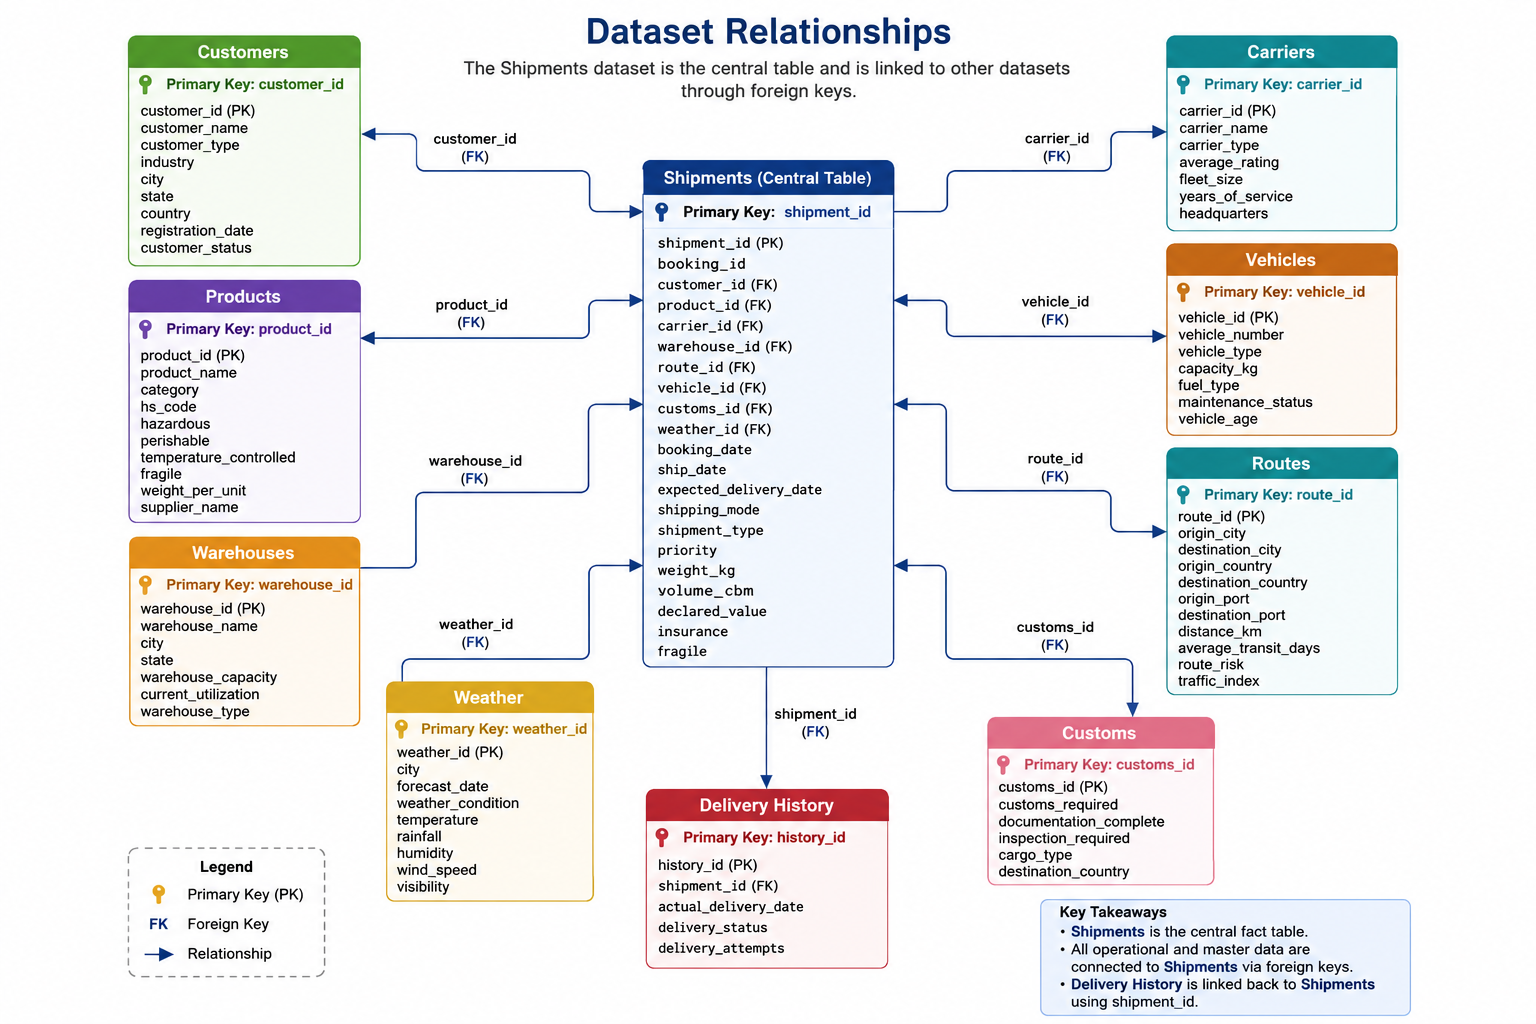.

# Join the dataset


## Reason for Using INNER JOIN

- Used **INNER JOIN** to merge the `shipments` table with all related datasets.
- Retained only records with matching data across all tables.
- Removed incomplete or unmatched records automatically.
- Created a clean, complete, and consistent master dataset.
- Improved data quality for feature engineering and machine learning.
- Ensured reliable and accurate model training.
```


In [302]:
# Create a master dataframe using INNER JOIN

df_master = (
    df_shipments
    
    # Customer Details
    .merge(df_customers, on="customer_id", how="inner")

    # Product Details
    .merge(df_products, on="product_id", how="inner", suffixes=("", "_product"))

    # Carrier Details
    .merge(df_carriers, on="carrier_id", how="inner", suffixes=("", "_carrier"))

    # Vehicle Details
    .merge(df_vehicles, on="vehicle_id", how="inner", suffixes=("", "_vehicle"))

    # Warehouse Details
    .merge(df_warehouses, on="warehouse_id", how="inner", suffixes=("", "_warehouse"))

    # Route Details
    .merge(df_routes, on="route_id", how="inner", suffixes=("", "_route"))

    # Weather Details
    .merge(df_weather, on="weather_id", how="inner", suffixes=("", "_weather"))

    # Customs Details
    .merge(df_customs, on="customs_id", how="inner", suffixes=("", "_customs"))

    # Delivery History
    .merge(df_delivery_history, on="shipment_id", how="inner", suffixes=("", "_delivery"))
)

In [303]:
df_master.shape

(1930, 83)

In [305]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1930 entries, 0 to 1929
Data columns (total 83 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   shipment_id                  1930 non-null   object 
 1   booking_id                   1930 non-null   object 
 2   customer_id                  1930 non-null   object 
 3   product_id                   1930 non-null   object 
 4   carrier_id                   1930 non-null   object 
 5   warehouse_id                 1930 non-null   object 
 6   route_id                     1930 non-null   object 
 7   vehicle_id                   1930 non-null   object 
 8   customs_id                   1930 non-null   object 
 9   weather_id                   1930 non-null   object 
 10  booking_date                 1930 non-null   object 
 11  ship_date                    1930 non-null   object 
 12  expected_delivery_date       1930 non-null   object 
 13  shipping_mode     

In [307]:
# Save the dataset in the current working directory
df_master.to_csv("df_master.csv", index=False)

print("Dataset saved successfully as df_master.csv")

Dataset saved successfully as df_master.csv
